# **Image Processing: Week 1 – Fondasi Citra Digital: Geometri, Warna, dan Anotasis**

Minggu ini kita akan mempelajari konsep fundamental dalam **pengolahan citra digital** dengan fokus pada representasi citra sebagai data, operasi dasar, transformasi geometris, serta anotasi visual. Teknik-teknik ini merupakan fondasi penting sebelum masuk ke analisis citra tingkat lanjut.

**Tujuan Pembelajaran:**

Di akhir sesi ini kita akan bisa:
- Memahami bagaimana gambar direpresentasikan sebagai data numerik.
- Melakukan operasi dasar citra seperti resize, crop, dan konversi warna.
- Menerapkan transformasi geometris: translasi, rotasi, dan scaling.
- Menambahkan anotasi visual (teks dan bentuk) ke citra.

> *This module is inspired by the development of last semester’s materials.* 

## **Pengantar**

### **Apa itu Gambar?**

Secara sederhana, **gambar digital** adalah matriks berisi nilai piksel.  
- Setiap **piksel** mewakili warna tertentu.  
- Intensitas warna ditentukan oleh nilai numerik pada piksel tersebut.  
- Gambar berwarna umumnya direpresentasikan dalam **3 channel warna**: **Merah (R), Hijau (G), dan Biru (B)**.  

Bayangkan gambar seperti lembar kerja **Microsoft Excel**: ada baris dan kolom. Bedanya, setiap sel tidak hanya berisi angka biasa, melainkan nilai yang menentukan warna. Hasil gabungan ribuan hingga jutaan piksel inilah yang membentuk sebuah citra digital.

*Sebelum lanjut, kita coba import library yang akan kita butuhkan dulu*

In [21]:
# Import library yang dibutuhkan
import numpy as np  # Untuk operasi numerik dan manipulasi array
import matplotlib.pyplot as plt  # Untuk visualisasi gambar
import cv2  # OpenCV: library utama untuk pengolahan citra dan aplikasi terkait
import os  # Untuk operasi file dan path
# import dlib  # Deteksi wajah & landmark
# import pyzbar  # Pembaca barcode / QR code

# Cek versi library yang diinstal
print(f"Versi numpy: {np.__version__}")
print(f"Versi matplotlib: {plt.matplotlib.__version__}")
print(f"Versi OpenCV: {cv2.__version__}")
# print("Versi dlib:", dlib.__version__)
# print("Versi pyzbar:", pyzbar.__file__)

"""
📌 Catatan Penting:
Beberapa library tambahan dibutuhkan untuk tugas-tugas berikutnya:

1. dlib → digunakan untuk deteksi wajah.
   - Instalasi di Windows bisa rumit.
   - Panduan lengkap: https://www.geeksforgeeks.org/python/how-to-install-dlib-library-for-python-in-windows-10/

2. pyzbar → digunakan untuk membaca barcode/QR code.
   - Jika error saat instalasi, gunakan:
     pip install pyzbar
   - Panduan: https://pypi.org/project/pyzbar/

💡 Disarankan menggunakan versi Python 3.10 atau 3.11 agar kompatibel.
"""

Versi numpy: 2.2.6
Versi matplotlib: 3.10.7
Versi OpenCV: 4.12.0


'\n📌 Catatan Penting:\nBeberapa library tambahan dibutuhkan untuk tugas-tugas berikutnya:\n\n1. dlib → digunakan untuk deteksi wajah.\n   - Instalasi di Windows bisa rumit.\n   - Panduan lengkap: https://www.geeksforgeeks.org/python/how-to-install-dlib-library-for-python-in-windows-10/\n\n2. pyzbar → digunakan untuk membaca barcode/QR code.\n   - Jika error saat instalasi, gunakan:\n     pip install pyzbar\n   - Panduan: https://pypi.org/project/pyzbar/\n\n💡 Disarankan menggunakan versi Python 3.10 atau 3.11 agar kompatibel.\n'

**Penjelasan Fungsi Penting:**
- `numpy` → manipulasi array dan operasi numerik dasar (pondasi semua data citra).
- `matplotlib` → visualisasi citra (menampilkan gambar, histogram, dsb).
- `cv2` (OpenCV) → operasi pengolahan citra utama seperti rotasi, cropping, filtering, dan anotasi.
- `os` → manajemen file dan path (berguna untuk mengatur folder data).
- `dlib` → pustaka kuat untuk face detection, facial landmark, dan analisis geometri wajah.
> 💡 Catatan: di Windows, instalasi dlib bisa agak tricky karena butuh CMake dan Visual Studio Build Tools.
Jika menemui error saat pip install dlib, pastikan kamu sudah menginstal CMake dan compiler C++ terbaru.
- `pyzbar` → digunakan untuk membaca barcode atau QR code dari gambar (praktis untuk latihan deteksi simbol visual).

## **Citra Sebagai Data**

Citra digital sebenarnya hanyalah matriks angka.
- Setiap angka = intensitas warna.
- Untuk citra berwarna, ada 3 channel: R (Red), G (Green), B (Blue).
- Untuk grayscale, cukup 1 channel.

- **Resolusi:** jumlah piksel (lebar x tinggi)
- **Color space:** RGB (warna), Grayscale (abu-abu), HSV (hue, saturation, value)

Bayangkan seperti spreadsheet Excel.
Setiap sel di sana bukan angka biasa, tapi intensitas warna piksel. Itulah yang sedang kita olah.

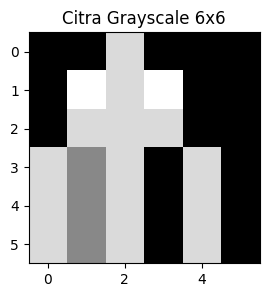

In [22]:
# Demo: Memuat, menampilkan, dan menyimpan citra
numpy_img_1ch = np.array([
    [0,   0,   128, 0, 0, 0],
    [0,   150,   128, 150, 0, 0],
    [0, 128, 128, 128, 0, 0],
    [128,  80,  128,   0,   128, 0],
    [128,  80,  128,   0,   128, 0],
    [128,  80,  128,   0,   128, 0],
], dtype=np.uint8)

# Tampilkan citra grayscale
plt.figure(figsize=(3,3))
plt.imshow(numpy_img_1ch, cmap='gray')
plt.title("Citra Grayscale 6x6")
plt.show()

**💭 Refleksi**
- Kenapa kita perlu `cmap='gray'` saat menampilkan gambar?
- Apa maksud dari `dtype=np.uint8`?

> Coba hilangkan argumen cmap='gray' dan lihat hasilnya!

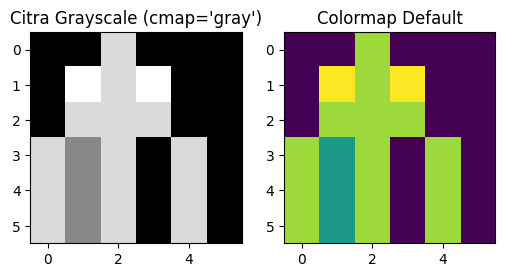

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(6,3))
axs[0].imshow(numpy_img_1ch, cmap='gray')
axs[0].set_title("Citra Grayscale (cmap='gray')")
axs[1].imshow(numpy_img_1ch)
axs[1].set_title("Colormap Default")
plt.show()

Channel Merah: 
[[  0   0 255   0 255]
 [  0   0 255   0   0]
 [255 255 255 255 255]
 [  0   0 255   0   0]
 [  0   0 255   0   0]]
Channel Hijau: 
[[255 255   0 255 255]
 [255 255   0 255 255]
 [  0   0   0   0   0]
 [255 255   0 255 255]
 [255 255   0 255 255]]
Channel Biru: 
[[  0   0   0   0 255]
 [  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]


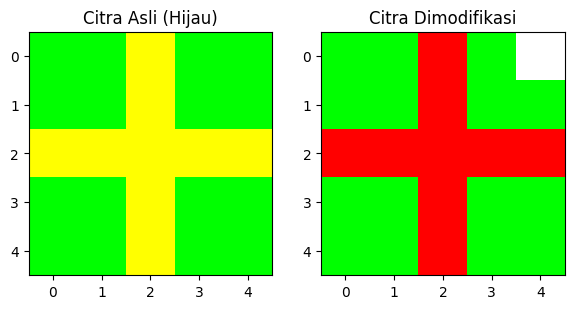

In [24]:
# Demo: Modifikasi piksel pada citra RGB
numpy_img_rgb = np.zeros((5, 5, 3), dtype=np.uint8)

# Set background hijau
numpy_img_rgb[:, :] = [0, 255, 0]

# Set kuning ke tengah citra
numpy_img_rgb[2, :] = [255, 255, 0]
numpy_img_rgb[:, 2] = [255, 255, 0]

# Salin untuk modifikasi
numpy_img_rgb_modified = numpy_img_rgb.copy()

# Buat plus merah di baris & kolom ke-2
numpy_img_rgb_modified[2, :] = [255, 0, 0]   
numpy_img_rgb_modified[:, 2] = [255, 0, 0]  

# Tambahkan titik putih di koordinat (0,4)
numpy_img_rgb_modified[0, 4] = [255, 255, 255]

# Tampilkan channel numeriknya
print(f"Channel Merah: \n{numpy_img_rgb_modified[:, :, 0]}")
print(f"Channel Hijau: \n{numpy_img_rgb_modified[:, :, 1]}")
print(f"Channel Biru: \n{numpy_img_rgb_modified[:, :, 2]}")

# Plot berdampingan
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

axs[0].imshow(numpy_img_rgb)  # asli hijau
axs[0].set_title("Citra Asli (Hijau)")

axs[1].imshow(numpy_img_rgb_modified) 
axs[1].set_title("Citra Dimodifikasi")

plt.tight_layout()
plt.show()

## **Operasi Dasar Citra**

Pada sesi ini, kita akan melakukan muat gambar, menampilkan, *resizing, cropping,* konversi warna, dan memisahkan channel warna.

### **Hands-On: 1. *Load* Gambar**

Muat gambar dengan `cv2.imread()` dan tampilkan dengan `matplotlib`. Langkah-langkahnya:

1. **Import Library**: Pastikan `cv2` dan `os` sudah di-import.
2. **Path Gambar**: Gunakan `os.path.join` untuk path yang kompatibel di semua OS.
3. **Load Gambar**: Pakai `cv2.imread(path)`, hasilnya array numpy.
4. **Tampilkan**: Gunakan `cv2.imshow` atau `matplotlib`.

> **Tips**: `os.path.join` bikin path lebih aman dan fleksibel di berbagai sistem operasi.


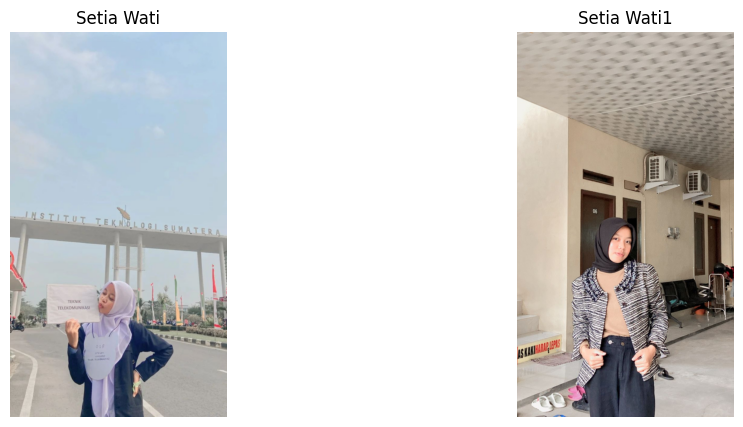

In [25]:
import cv2
import matplotlib.pyplot as plt

# Path gambar
img_path = os.path.join(os.getcwd(), 'data', 'Setia Wati.jpg')
img2_path = os.path.join(os.getcwd(), 'data', 'Setia Wati1.jpg')

# Baca gambar
img = cv2.imread(img_path)
img2 = cv2.imread(img2_path)

# Konversi warna
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Tampilkan
fig, axs = plt.subplots(1,2, figsize=(12,5))

axs[0].imshow(img_rgb)
axs[0].set_title("Setia Wati")
axs[0].axis('off')

axs[1].imshow(img2_rgb)
axs[1].set_title("Setia Wati1")
axs[1].axis('off')

plt.show()

> **Pertanyaan:** Mengapa kita harus melakukan `cv2.cvtColor cv2.COLOR_BGR2RGB`?

In [26]:
import os
print(os.listdir())

['.git', '.idea', '.ipynb_checkpoints', '00_lecturing_28_october.ipynb', '10_image_processing_week3.ipynb', '11_image_procesing_exercise.ipynb', '12_video_processing_week1.ipynb', '13_video_processing_week2.ipynb', '14_video_processing_week3.ipynb', '1_loading_media_audio.ipynb', '2025_1', '2_loading_media_image_vid.ipynb', '3_exercise_loading_media.ipynb', '4_audio_processing_week1.ipynb', '5_audio_processing_week2.ipynb', '6_audio_processing_week3.ipynb', '7_audio_processing_exercise.ipynb', '8_image_processing_week1.ipynb', '9_image_processing_week2.ipynb', 'data', 'mmod_human_face_detector.dat', 'open_camera.py', 'readme.md', 'shape_predictor_68_face_landmarks.dat']


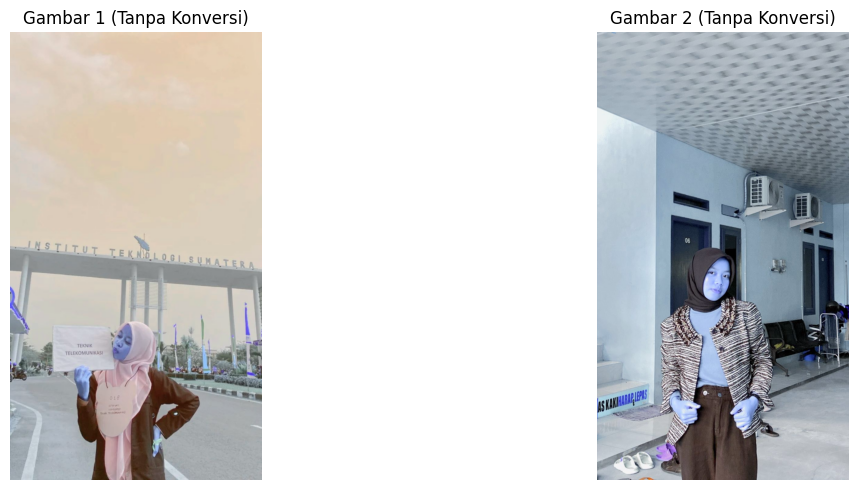

In [27]:
# Load gambar original tanpa cvtColor
import cv2
import matplotlib.pyplot as plt
img_bgr = cv2.imread(img_path)
img2_bgr = cv2.imread(img2_path)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].imshow(img_bgr)
axs[0].set_title('Gambar 1 (Tanpa Konversi)')
axs[0].axis('off')

axs[1].imshow(img2_bgr)
axs[1].set_title('Gambar 2 (Tanpa Konversi)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [28]:
# Menyimpan gambar
# Tentukan folder output
output_folder = os.path.dirname(img_path)

# Simpan gambar dalam berbagai format
cv2.imwrite(os.path.join(output_folder, 'gambar_output.jpg'), img_bgr)
cv2.imwrite(os.path.join(output_folder, 'gambar_output.png'), img_bgr)

# Mengontrol kualitas JPEG (0-100)
cv2.imwrite(os.path.join(output_folder, 'gambar_kualitas_tinggi.jpg'), img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
cv2.imwrite(os.path.join(output_folder, 'gambar_kualitas_rendah.jpg'), img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 30])

True

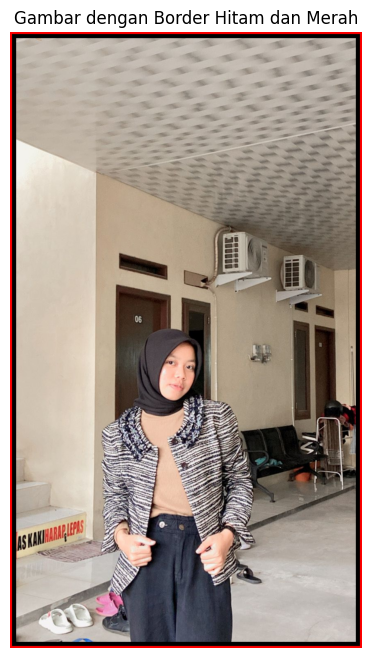

In [29]:
# Materi di kelas: Menambahkan border hitam 10px dan border merah 5px pada gambar1
border_black = 10
border_red = 5

# Dimensi gambar asli
height, width, channels = img2_rgb.shape

# Membuat array baru untuk gambar dengan border hitam
img_with_black_border = np.zeros((height + 2 * border_black, width + 2 * border_black, channels), dtype=np.uint8)
img_with_black_border[border_black:-border_black, border_black:-border_black] = img2_rgb

# Membuat array baru untuk gambar dengan border merah
img_with_red_border = np.zeros((height + 2 * (border_black + border_red), width + 2 * (border_black + border_red), channels), dtype=np.uint8)
img_with_red_border[:, :] = [255, 0, 0]  # Warna merah
img_with_red_border[border_red:-border_red, border_red:-border_red] = img_with_black_border

# Plot hasil
plt.figure(figsize=(8, 8))
plt.imshow(img_with_red_border)
plt.title("Gambar dengan Border Hitam dan Merah")
plt.axis("off")
plt.show()

Shape img2_rgb: (1472, 828, 3)


(np.float64(-0.5), np.float64(827.5), np.float64(1471.5), np.float64(-0.5))

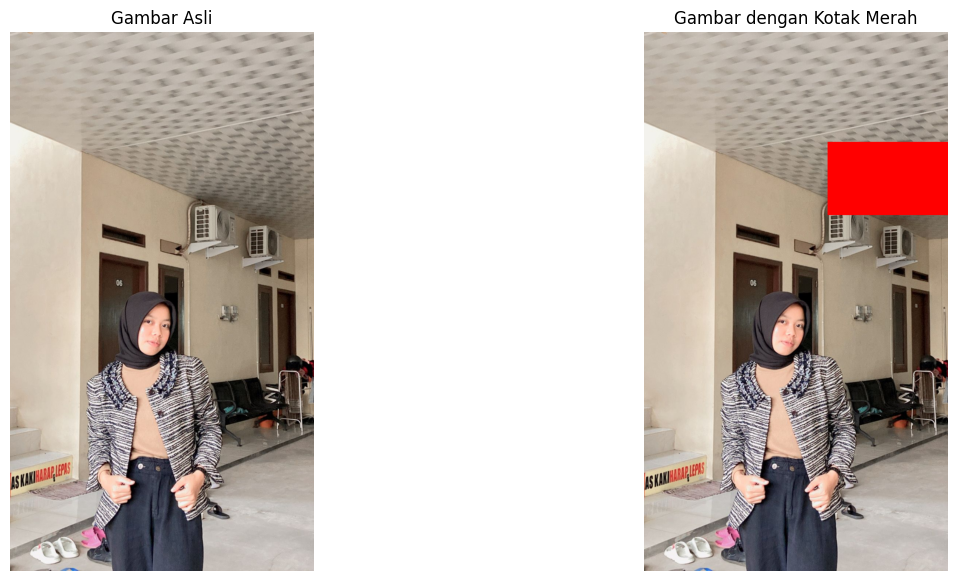

In [30]:
# Materi di kelas: Mencoba memanipulasi warna di koordinat tertentu dan juga menampilkan tanpa matplotlib
from IPython.display import display

# Tampilkan shape gambar
print("Shape img2_rgb:", img2_rgb.shape)

# Koordinat untuk kotak hijau
x1, y1 = 500, 300  # Koordinat kiri atas
x2, y2 = 1000, 500  # Koordinat kanan bawah

# Salin gambar untuk manipulasi
img2_rgb_green_box = img2_rgb.copy()

# Ubah warna menjadi hijau di area tertentu
img2_rgb_green_box[y1:y2, x1:x2] = [255, 0, 0]  # Warna hijau (R=0, G=255, B=0)

# Plot gambar asli dan hasil manipulasi
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Gambar asli
axs[0].imshow(img2_rgb)
axs[0].set_title("Gambar Asli")
axs[0].axis("off")

# Gambar dengan kotak merah
axs[1].imshow(img2_rgb_green_box)
axs[1].set_title("Gambar dengan Kotak Merah")
axs[1].axis("off")

📌 **Cheatsheet OpenCV Dasar**

**Membaca Gambar (`cv2.imread`)**
- **IMREAD_COLOR** → default, format BGR  
- **IMREAD_GRAYSCALE** → hitam putih  
- **IMREAD_UNCHANGED** → asli (misal RGBA)  

**Menyimpan Gambar (`cv2.imwrite`)**
- Simpan ke `.jpg`, `.png`, dll  
- **IMWRITE_JPEG_QUALITY** → kontrol kualitas (0–100)  
- **IMWRITE_PNG_COMPRESSION** → kontrol kompresi (0–9)  

**Menampilkan Gambar (`cv2.imshow`)**
- Membuka jendela gambar  
- Gunakan `waitKey` untuk pause & `destroyAllWindows` untuk menutup  

**Informasi Gambar**
- `.shape` → ukuran (rows, cols, channels)  

**Operasi Dasar**
- **Resize (`cv2.resize`)** → ubah ukuran / skala gambar  
- **Color Conversion (`cv2.cvtColor`)** → ubah BGR ↔ RGB ↔ Grayscale  


### **Hands-On: 2. *Resize* (Mengubah Ukuran Gambar)**

*Resize* adalah proses **mengubah dimensi gambar** sesuai kebutuhan. Proses ini sering dilakukan untuk:

- Mengurangi ukuran file gambar  
- Menyesuaikan dengan resolusi layar atau halaman web  
- Normalisasi ukuran input untuk model pembelajaran mesin  

**Cara Kerja:**
- Fungsi utama: `cv2.resize()`
- Parameter utama: `(width, height)` dalam bentuk tuple
- Pemilihan **metode interpolasi** berpengaruh pada kualitas hasil:
  - `cv2.INTER_LINEAR` → default, baik untuk memperbesar
  - `cv2.INTER_AREA` → terbaik untuk memperkecil
  - `cv2.INTER_CUBIC` dan `cv2.INTER_LANCZOS4` → kualitas tinggi, lebih halus untuk memperbesar


Shape img2_rgb: (1472, 828, 3)
Tinggi gambar: 1472 piksel
Lebar gambar: 828 piksel
Jumlah channel: 3 (RGB)


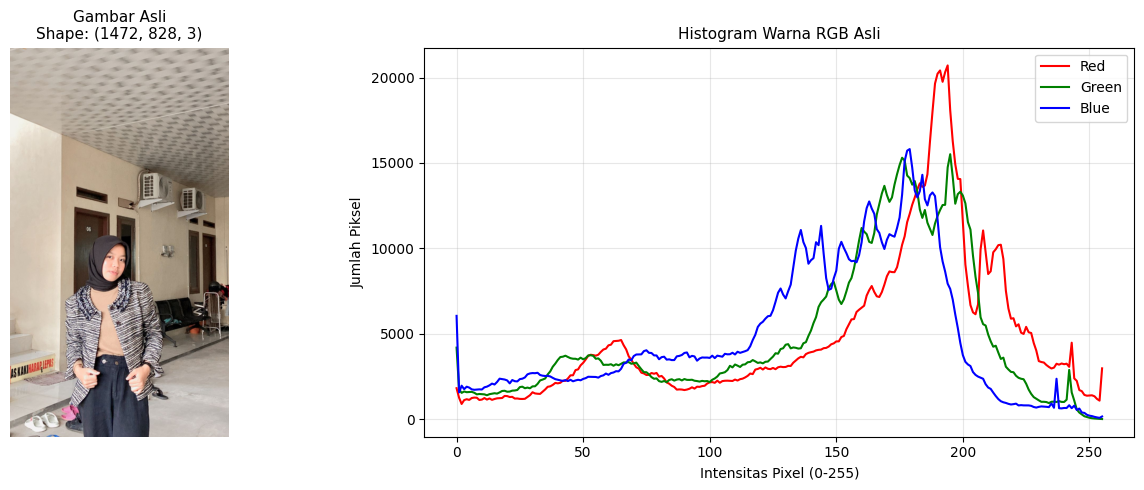

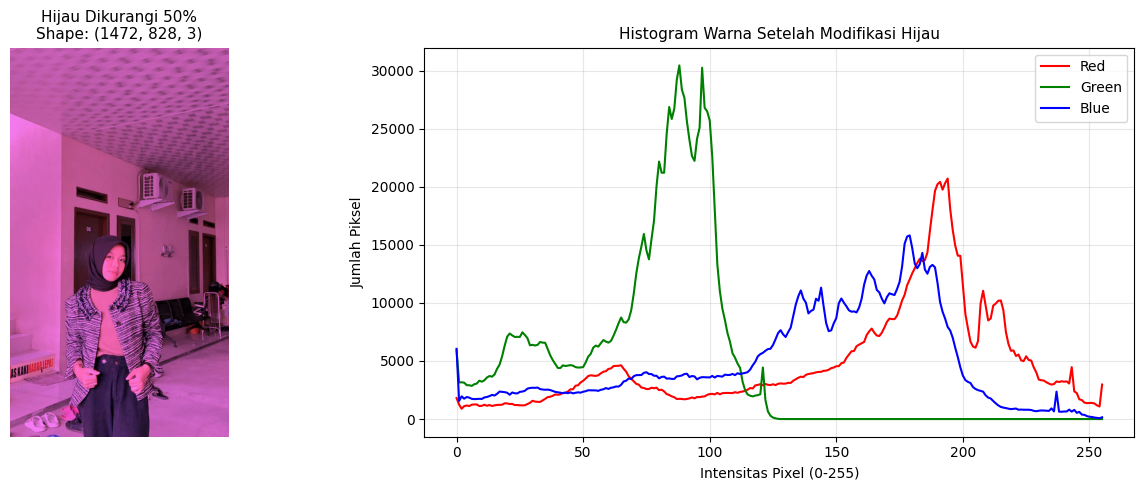


=== Penjelasan cv2.calcHist ===
cv2.calcHist([gambar], [channel], mask, [bins], [range])
- [gambar]: gambar input dalam list
- [channel]: channel yang ingin dihitung (0=R, 1=G, 2=B)
- mask: None berarti semua piksel dihitung
- [bins]: jumlah interval histogram (256 untuk 0-255)
- [range]: rentang nilai piksel [0,256)


In [31]:
# Mengecek shape dari gambar
print("Shape img2_rgb:", img2_rgb.shape)  # (tinggi, lebar, channel)
print("Tinggi gambar:", img2_rgb.shape[0], "piksel")
print("Lebar gambar:", img2_rgb.shape[1], "piksel")
print("Jumlah channel:", img2_rgb.shape[2], "(RGB)")

# Tampilkan gambar + histogram dalam 1 layout
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Gambar asli
axs[0].imshow(img2_rgb)
axs[0].set_title(f"Gambar Asli\nShape: {img2_rgb.shape}", fontsize=11)
axs[0].axis('off')

# Histogram RGB asli
colors = ('r','g','b')
labels = ('Red','Green','Blue')
for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img2_rgb], [i], None, [256], [0,256])
    axs[1].plot(hist, color=col, label=label)

axs[1].set_title("Histogram Warna RGB Asli", fontsize=11)
axs[1].set_xlabel("Intensitas Pixel (0-255)")
axs[1].set_ylabel("Jumlah Piksel")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Modifikasi: Kurangi intensitas warna hijau (G) menjadi setengah
img2_mod = img2_rgb.copy()
img2_mod[:,:,1] = (img2_mod[:,:,1] * 0.5).astype(np.uint8)

# Tampilkan gambar hasil modifikasi
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Gambar hasil modifikasi
axs[0].imshow(img2_mod)
axs[0].set_title("Hijau Dikurangi 50%\nShape: {}".format(img2_mod.shape), fontsize=11)
axs[0].axis('off')

# Histogram setelah modifikasi
for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img2_mod], [i], None, [256], [0,256])
    axs[1].plot(hist, color=col, label=label)

axs[1].set_title("Histogram Warna Setelah Modifikasi Hijau", fontsize=11)
axs[1].set_xlabel("Intensitas Pixel (0-255)")
axs[1].set_ylabel("Jumlah Piksel")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Penjelasan calcHist
print("\n=== Penjelasan cv2.calcHist ===")
print("cv2.calcHist([gambar], [channel], mask, [bins], [range])")
print("- [gambar]: gambar input dalam list")
print("- [channel]: channel yang ingin dihitung (0=R, 1=G, 2=B)")
print("- mask: None berarti semua piksel dihitung")
print("- [bins]: jumlah interval histogram (256 untuk 0-255)")
print("- [range]: rentang nilai piksel [0,256)")


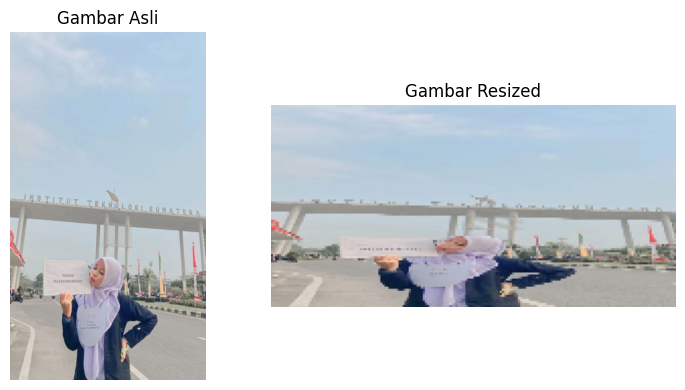

In [32]:
# Melakukan perubahan ukuran pada gambar (resizing)
img_resized = cv2.resize(img, (200, 100))
img_resized_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

# Plot hasil
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# Original
axs[0].imshow(img_rgb)
axs[0].set_title("Gambar Asli")
axs[0].axis("off")

# Cropped
axs[1].imshow(img_resized_rgb)
axs[1].set_title("Gambar Resized")
axs[1].axis("off")

plt.tight_layout()
plt.show()

### **Hands-On: 3. *Crop* (Memotong Gambar)**
*Crop* adalah proses memotong bagian tertentu dari gambar, seperti memperbesar objek tertentu atau menghilangkan latar belakang yang tidak diperlukan.

**Cara Kerja:**
- Gambar direpresentasikan sebagai array numpy dengan format `[height, width, channels]`.
- *Crop* dilakukan dengan slicing array numpy:
  - `cropped_image = image[y1:y2, x1:x2]`
  - `y1`, `y2` adalah batas vertikal, dan `x1`, `x2` adalah batas horizontal.


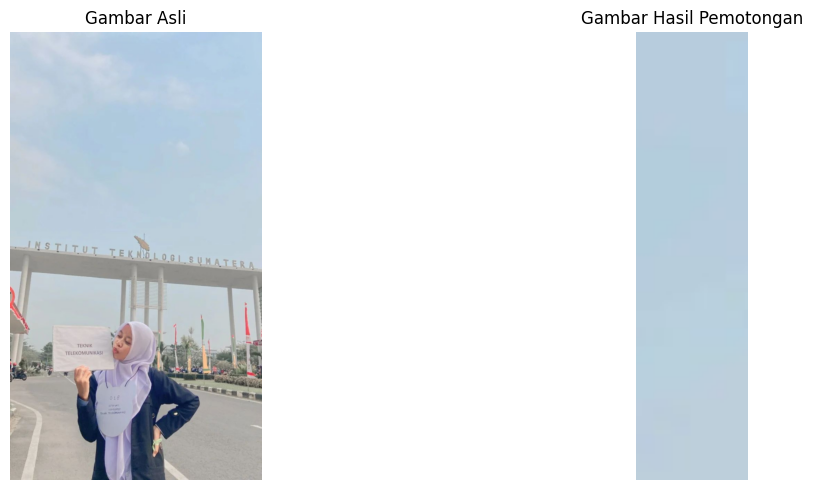

In [33]:
# Melakukan pemotongan
img_cropped_original = img[300:500, 600:650]

# Plot gambar
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Original no Crop
axs[0].imshow(img_rgb)
axs[0].set_title('Gambar Asli')
axs[0].axis('off')

# Original cropped image
axs[1].imshow(cv2.cvtColor(img_cropped_original, cv2.COLOR_BGR2RGB))
axs[1].set_title('Gambar Hasil Pemotongan')
axs[1].axis('off')

plt.tight_layout()
plt.show()


**Latihan**
Di bawah ini, kita akan coba untuk memotong gambar menjadi setengah tingginya.

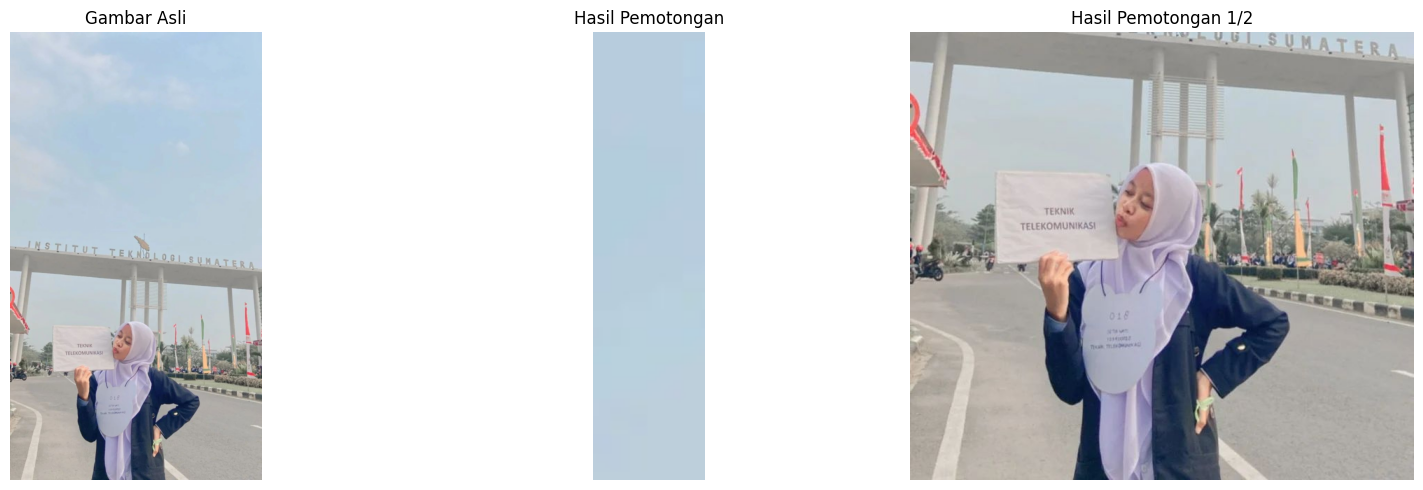

In [34]:
img_cropped_modification = img[img.shape[0]//2:, :]

# Plot 
fig, axs = plt.subplots(1, 3, figsize=(17, 5))

# Original no Crop
axs[0].imshow(img_rgb)
axs[0].set_title('Gambar Asli')
axs[0].axis('off')

# Original cropped image
axs[1].imshow(cv2.cvtColor(img_cropped_original, cv2.COLOR_BGR2RGB))
axs[1].set_title('Hasil Pemotongan')
axs[1].axis('off')

# Original cropped image modif
axs[2].imshow(cv2.cvtColor(img_cropped_modification, cv2.COLOR_BGR2RGB))
axs[2].set_title('Hasil Pemotongan 1/2')
axs[2].axis('off')

plt.tight_layout()
plt.show()

### **Hands-On: 4. *Flip* (Membalik Gambar)**

*Flip* adalah proses membalik gambar secara horizontal, vertikal, atau keduanya. Proses ini sering digunakan untuk augmentasi data atau untuk mencerminkan gambar.

**Cara Kerja:**
- Gambar direpresentasikan sebagai array numpy dengan format `[height, width, channels]`.
- *Flip* dilakukan menggunakan fungsi `cv2.flip()`:
    - `cv2.flip(image, 0)` → Membalik gambar secara vertikal.
    - `cv2.flip(image, 1)` → Membalik gambar secara horizontal.
    - `cv2.flip(image, -1)` → Membalik gambar secara horizontal dan vertikal.

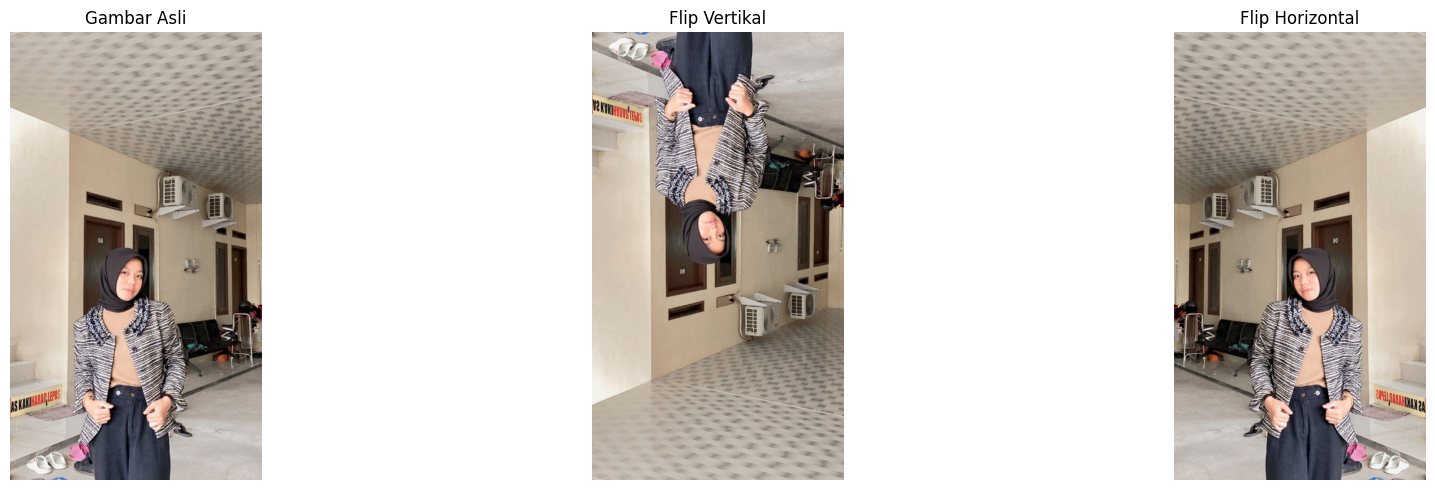

In [35]:
# Membalik gambar secara vertikal, horizontal, dan keduanya
img_flip_vertical = cv2.flip(img2_rgb, 0)  # Membalik vertikal
img_flip_horizontal = cv2.flip(img2_rgb, 1)  # Membalik horizontal

# Plot hasil
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# Gambar asli
axs[0].imshow(img2_rgb)
axs[0].set_title("Gambar Asli")
axs[0].axis('off')

# Flip vertikal
axs[1].imshow(img_flip_vertical)
axs[1].set_title("Flip Vertikal")
axs[1].axis('off')

# Flip horizontal
axs[2].imshow(img_flip_horizontal)
axs[2].set_title("Flip Horizontal")
axs[2].axis('off')

plt.tight_layout()
plt.show()

### **Hands-On: 5. Konversi Antar Ruang Warna**

Pada sesi ini, kita akan melakukan konversi antara ruang warna (RGB ke Grayscale/HSV).

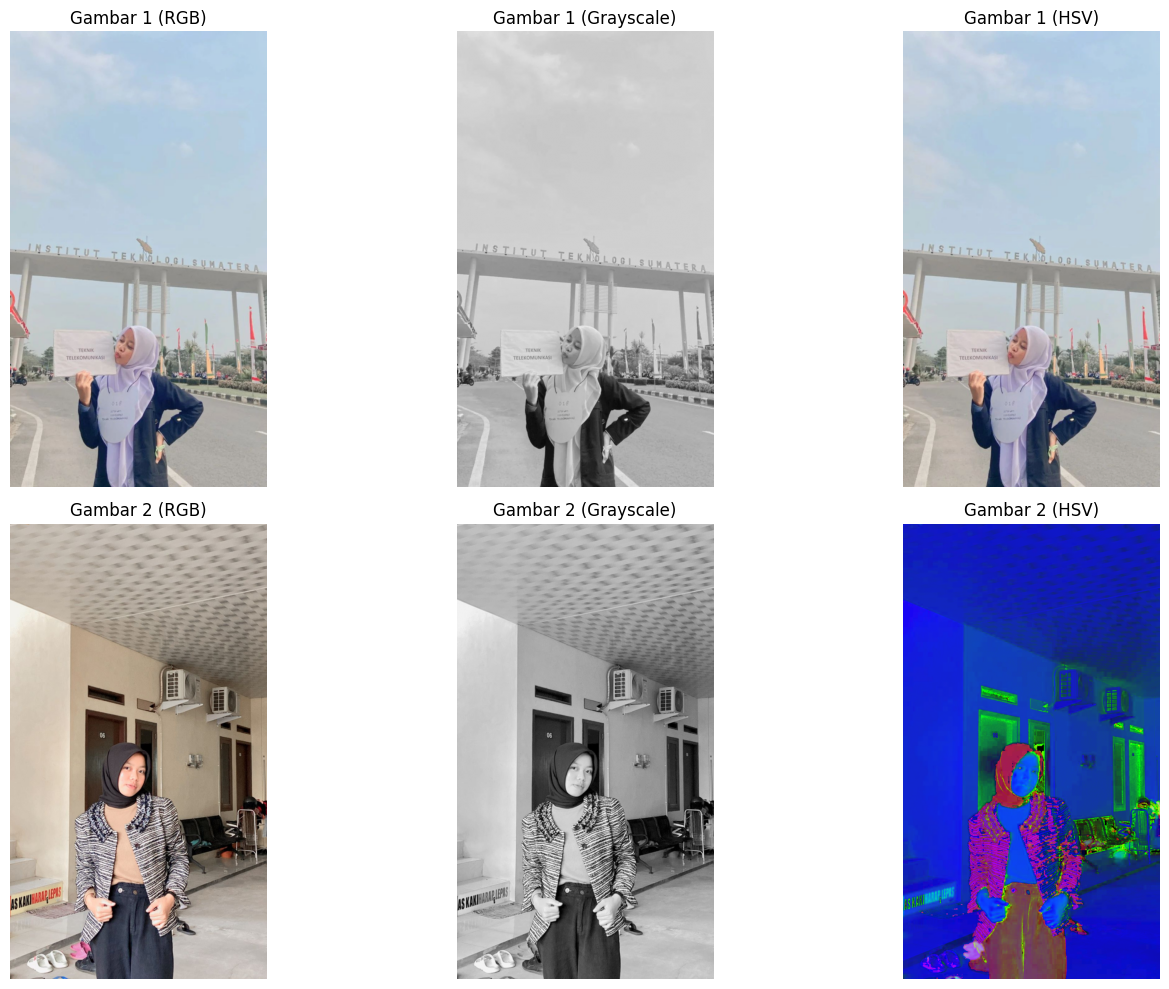

In [36]:
# Konversi RGB ke Grayscale dan HSV untuk img
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Konversi RGB ke Grayscale dan HSV untuk img2
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
img2_hsv = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)

# Plot hasil konversi
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Gambar 1
axs[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0, 0].set_title("Gambar 1 (RGB)")
axs[0, 0].axis('off')

axs[0, 1].imshow(img_gray, cmap='gray')
axs[0, 1].set_title("Gambar 1 (Grayscale)")
axs[0, 1].axis('off')

axs[0, 2].imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB))
axs[0, 2].set_title("Gambar 1 (HSV)")
axs[0, 2].axis('off')

# Gambar 2
axs[1, 0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axs[1, 0].set_title("Gambar 2 (RGB)")
axs[1, 0].axis('off')

axs[1, 1].imshow(img2_gray, cmap='gray')
axs[1, 1].set_title("Gambar 2 (Grayscale)")
axs[1, 1].axis('off')

axs[1, 2].imshow(img2_hsv)
axs[1, 2].set_title("Gambar 2 (HSV)")
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()

### **Hands-On: 6. Memisahkan dan menampilkan channel warna.**

Pada sesi ini, kita akan memisahkan dan menampilkan channel warna.

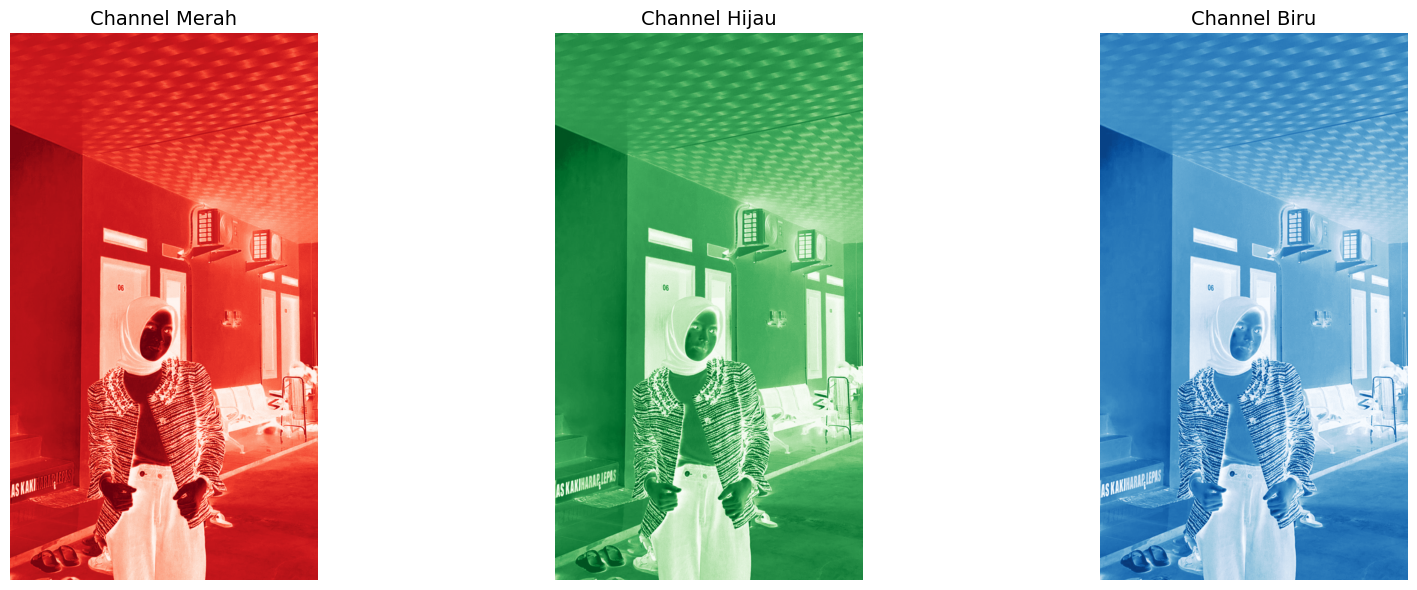

In [37]:
# Pisahkan channel warna
red_channel = img2_rgb[:, :, 0]
green_channel = img2_rgb[:, :, 1]
blue_channel = img2_rgb[:, :, 2]

# Tampilkan channel warna
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Channel Merah
axs[0].imshow(red_channel, cmap='Reds')
axs[0].set_title("Channel Merah", fontsize=14)
axs[0].axis('off')

# Channel Hijau
axs[1].imshow(green_channel, cmap='Greens')
axs[1].set_title("Channel Hijau", fontsize=14)
axs[1].axis('off')

# Channel Biru
axs[2].imshow(blue_channel, cmap='Blues')
axs[2].set_title("Channel Biru", fontsize=14)
axs[2].axis('off')

plt.tight_layout()
plt.show()

**Latihan**

Mencoba memodifikasi gambar HSV kemudian mengembalikannya dengan RGB

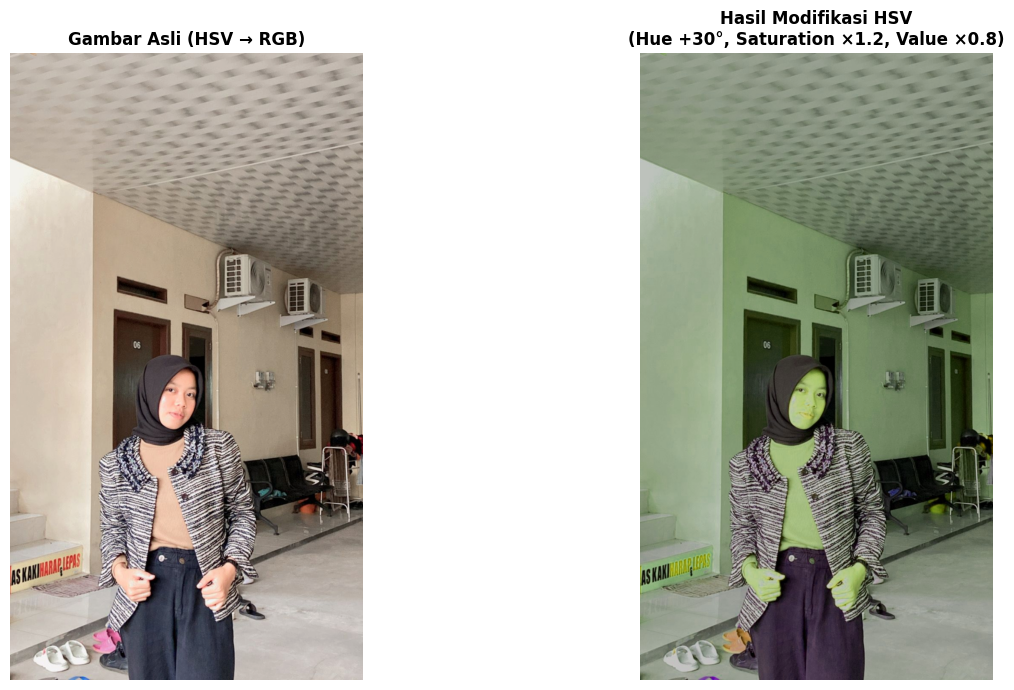

In [38]:
# Salin gambar HSV untuk dimodifikasi
img_hsv_modified = img2_hsv.copy().astype(np.float32)

# Modifikasi nilai H, S, dan V
img_hsv_modified[:, :, 0] = (img_hsv_modified[:, :, 0] + 30) % 180        # Hue digeser 30 derajat
img_hsv_modified[:, :, 1] = np.clip(img_hsv_modified[:, :, 1] * 1.2, 0, 255)  # Saturation diperkuat 20%
img_hsv_modified[:, :, 2] = np.clip(img_hsv_modified[:, :, 2] * 0.8, 0, 255)  # Value diredupkan 20%

img_hsv_modified = img_hsv_modified.astype(np.uint8)

# Konversi ke RGB 
img_rgb_original = cv2.cvtColor(img2_hsv, cv2.COLOR_HSV2RGB)
img_rgb_modified = cv2.cvtColor(img_hsv_modified, cv2.COLOR_HSV2RGB)

# Plot gambar asli dan hasil modifikasi
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Gambar asli
axs[0].imshow(img_rgb_original)
axs[0].set_title("Gambar Asli (HSV → RGB)", fontsize=12, fontweight='bold')
axs[0].axis('off')

# Gambar hasil modifikasi
axs[1].imshow(img_rgb_modified)
axs[1].set_title("Hasil Modifikasi HSV\n(Hue +30°, Saturation ×1.2, Value ×0.8)", fontsize=12, fontweight='bold')
axs[1].axis('off')

plt.tight_layout()
plt.show()


## **Transformasi Geometris**

Transformasi geometris meliputi translasi (menggeser), rotasi (memutar), dan scaling (mengubah ukuran).

- **Translasi:** Menggeser posisi gambar.
- **Rotasi:** Memutar gambar pada sudut tertentu.
- **Scaling:** Mengubah ukuran gambar.

Semua transformasi ini dapat direpresentasikan dengan matriks transformasi.

### **Hands-On: Manipulasi Piksel dan Dimensi Gambar**

Gambar digital adalah kumpulan piksel dengan nilai warna **RGB** (Red, Green, Blue) dalam rentang **0–255**.  
Kenapa 0–255? Karena format **8-bit per channel** memungkinkan 256 nilai unik (2⁸).  
- **0** = intensitas terendah (hitam).  
- **255** = intensitas tertinggi (putih).  

Setiap gambar memiliki atribut `.shape` yang menunjukkan dimensi: `(tinggi, lebar, channel)`.  
Contoh: `(1024, 1536, 3)` berarti gambar berwarna dengan 1024 piksel tinggi, 1536 piksel lebar, dan 3 channel warna.  

Mari kita eksplorasi lebih jauh dengan memanipulasi posisi dan orientasi piksel!


Shape img2_rgb: (1472, 828, 3)
Tinggi gambar: 1472 piksel
Lebar gambar: 828 piksel
Jumlah channel: 3 (RGB)
Isi dari row5_column5_img1:
[[[192 183 174]
  [193 184 175]
  [195 186 177]
  [196 187 178]
  [196 187 178]]

 [[193 184 175]
  [194 185 176]
  [195 186 177]
  [196 187 178]
  [197 188 179]]

 [[194 185 176]
  [195 186 177]
  [195 186 177]
  [195 186 177]
  [195 186 177]]

 [[193 184 175]
  [193 184 175]
  [193 184 175]
  [194 185 176]
  [195 186 177]]

 [[192 183 174]
  [193 184 175]
  [194 185 176]
  [197 188 179]
  [200 191 182]]]


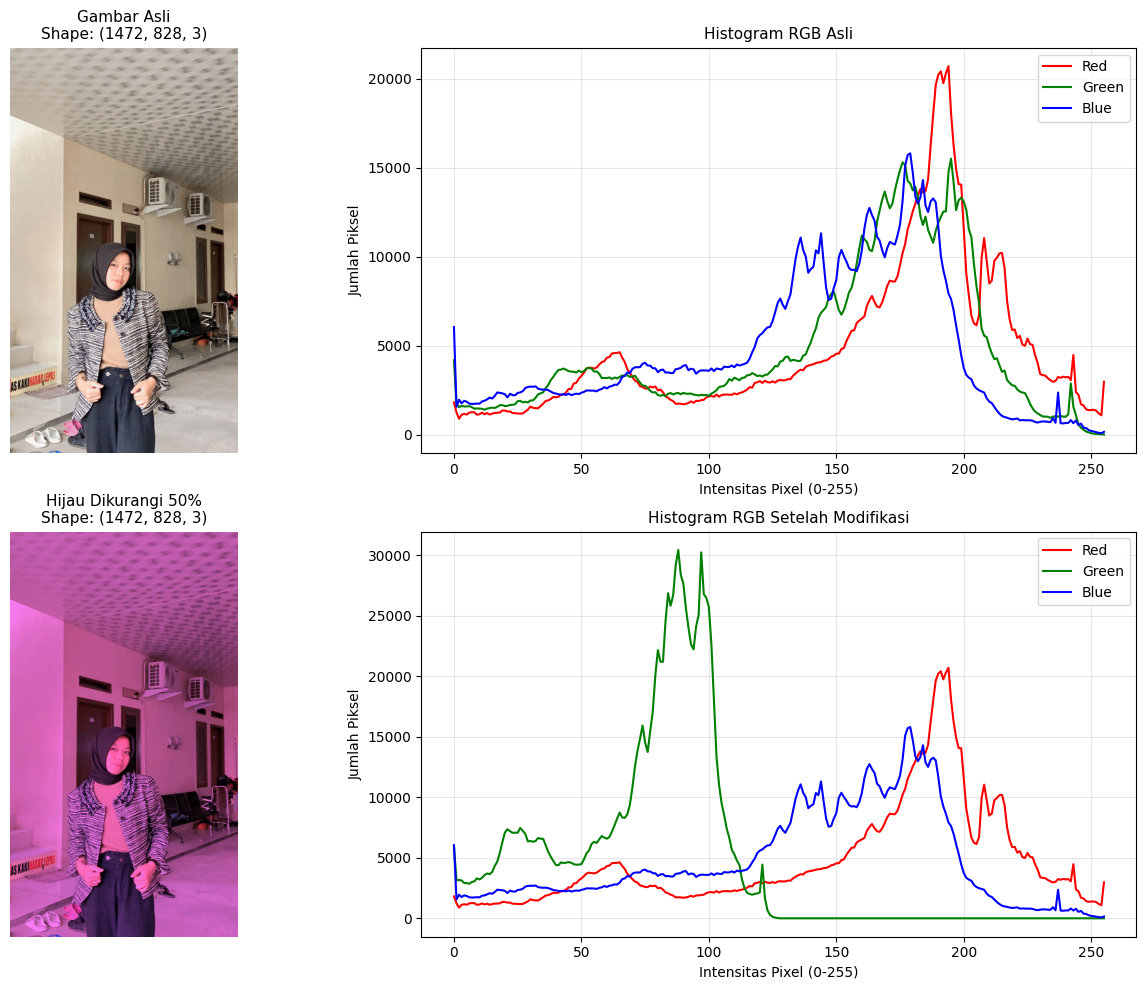


=== Penjelasan cv2.calcHist ===
cv2.calcHist([gambar], [channel], mask, [bins], [range])
- [gambar]: gambar input dalam list
- [channel]: channel yang ingin dihitung (0=R, 1=G, 2=B)
- mask: None berarti semua piksel dihitung
- [bins]: jumlah interval histogram (256 untuk 0-255)
- [range]: rentang nilai piksel [0,256)


In [39]:
# Mengecek shape dari gambar
print("Shape img2_rgb:", img2_rgb.shape)
print("Tinggi gambar:", img2_rgb.shape[0], "piksel")
print("Lebar gambar:", img2_rgb.shape[1], "piksel")
print("Jumlah channel:", img2_rgb.shape[2], "(RGB)")
row5_column5 = img2_rgb[0:5, 0:5]
print(f"Isi dari row5_column5_img1:\n{row5_column5}")

# Modifikasi: Kurangi intensitas warna hijau (G) menjadi setengah
img2_mod = img2_rgb.copy()
img2_mod[:,:,1] = (img2_mod[:,:,1] * 0.5).astype(np.uint8)

# Buat layout 2x2
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

colors = ('r','g','b')
labels = ('Red','Green','Blue')

# Gambar Asli
axs[0,0].imshow(img2_rgb)
axs[0,0].set_title(f"Gambar Asli\nShape: {img2_rgb.shape}", fontsize=11)
axs[0,0].axis('off')

# Histogram Asli
for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img2_rgb], [i], None, [256], [0,256])
    axs[0,1].plot(hist, color=col, label=label)
axs[0,1].set_title("Histogram RGB Asli", fontsize=11)
axs[0,1].set_xlabel("Intensitas Pixel (0-255)")
axs[0,1].set_ylabel("Jumlah Piksel")
axs[0,1].legend()
axs[0,1].grid(True, alpha=0.3)

# Gambar Modifikasi
axs[1,0].imshow(img2_mod)
axs[1,0].set_title(f"Hijau Dikurangi 50%\nShape: {img2_mod.shape}", fontsize=11)
axs[1,0].axis('off')

# Histogram Modifikasi
for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img2_mod], [i], None, [256], [0,256])
    axs[1,1].plot(hist, color=col, label=label)
axs[1,1].set_title("Histogram RGB Setelah Modifikasi", fontsize=11)
axs[1,1].set_xlabel("Intensitas Pixel (0-255)")
axs[1,1].set_ylabel("Jumlah Piksel")
axs[1,1].legend()
axs[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Penjelasan calcHist
print("\n=== Penjelasan cv2.calcHist ===")
print("cv2.calcHist([gambar], [channel], mask, [bins], [range])")
print("- [gambar]: gambar input dalam list")
print("- [channel]: channel yang ingin dihitung (0=R, 1=G, 2=B)")
print("- mask: None berarti semua piksel dihitung")
print("- [bins]: jumlah interval histogram (256 untuk 0-255)")
print("- [range]: rentang nilai piksel [0,256)")


### **Hands-On: Transformasi Posisi dan Orientasi Piksel**

Transformasi pada citra berarti **mengubah posisi, arah, atau ukuran piksel** menggunakan operasi matematis berbasis matriks.

#### **1. Translasi (Perpindahan)**

Menggeser seluruh piksel sejauh nilai tertentu pada sumbu x dan y.

➡ Tidak mengubah warna piksel, hanya posisinya.

➡ Area yang keluar dari batas gambar hilang, dan bagian kosong diisi warna latar.

#### **2. Rotasi (Perputaran)**

Memutar seluruh citra terhadap titik pusat.

➡ Mengubah orientasi gambar tanpa mengubah nilai warna.

➡ Dapat menimbulkan area kosong atau potongan di tepi gambar.

#### **3. Scaling (Penskalaan)**

Mengubah ukuran gambar dengan faktor `(s_x, s_y)`.

➡ Saat diperbesar, piksel lama direplikasi → detail menurun.

➡ Saat diperkecil, beberapa piksel digabung → sebagian data visual hilang.

➡ Scaling mempengaruhi **ketajaman dan jumlah informasi** dalam citra.

#### **4. Kombinasi Transformasi**

Beberapa transformasi dapat digabung secara berurutan.

➡ Urutan operasi berpengaruh pada hasil akhir.

➡ Secara matematis direpresentasikan melalui **perkalian matriks transformasi**.

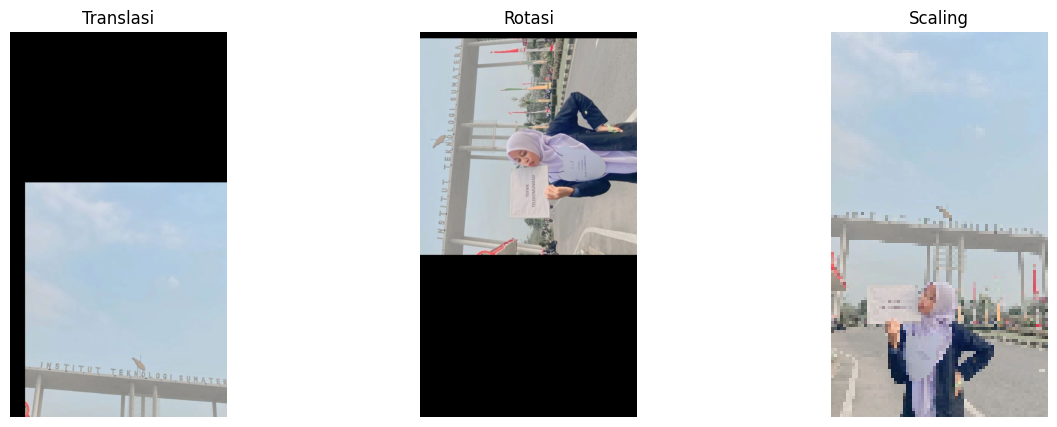

In [40]:
# Demo transformasi: translasi, rotasi, scaling
rows, cols = img_rgb.shape[:2]

# Translasi
M_trans = np.float32([[1, 0, 50], [0, 1, 500]])  # Geser 50px kanan, 30px bawah
img_trans = cv2.warpAffine(img_rgb, M_trans, (cols, rows))

# Rotasi
M_rot = cv2.getRotationMatrix2D((100, rows/2), 90, 1)  # Rotasi 30 derajat
img_rot = cv2.warpAffine(img_rgb, M_rot, (cols, rows))

# Scaling
img_scale = cv2.resize(img_rgb, None, fx=0.1, fy=0.1)

# Tampilkan hasil
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(img_trans); axs[0].set_title('Translasi')
axs[1].imshow(img_rot); axs[1].set_title('Rotasi')
axs[2].imshow(img_scale); axs[2].set_title('Scaling')
for ax in axs: ax.axis('off')
plt.show()

## **Transformasi & Anotasi**

Pada sesi ini, kita akan memutar gambar 45 derajat tanpa terpotong, menggeser objek, dan menambahkan anotasi visual.

### **Hands-On: Memutar Gambar Sebesar 45 Derajat Tanpa Memotong**

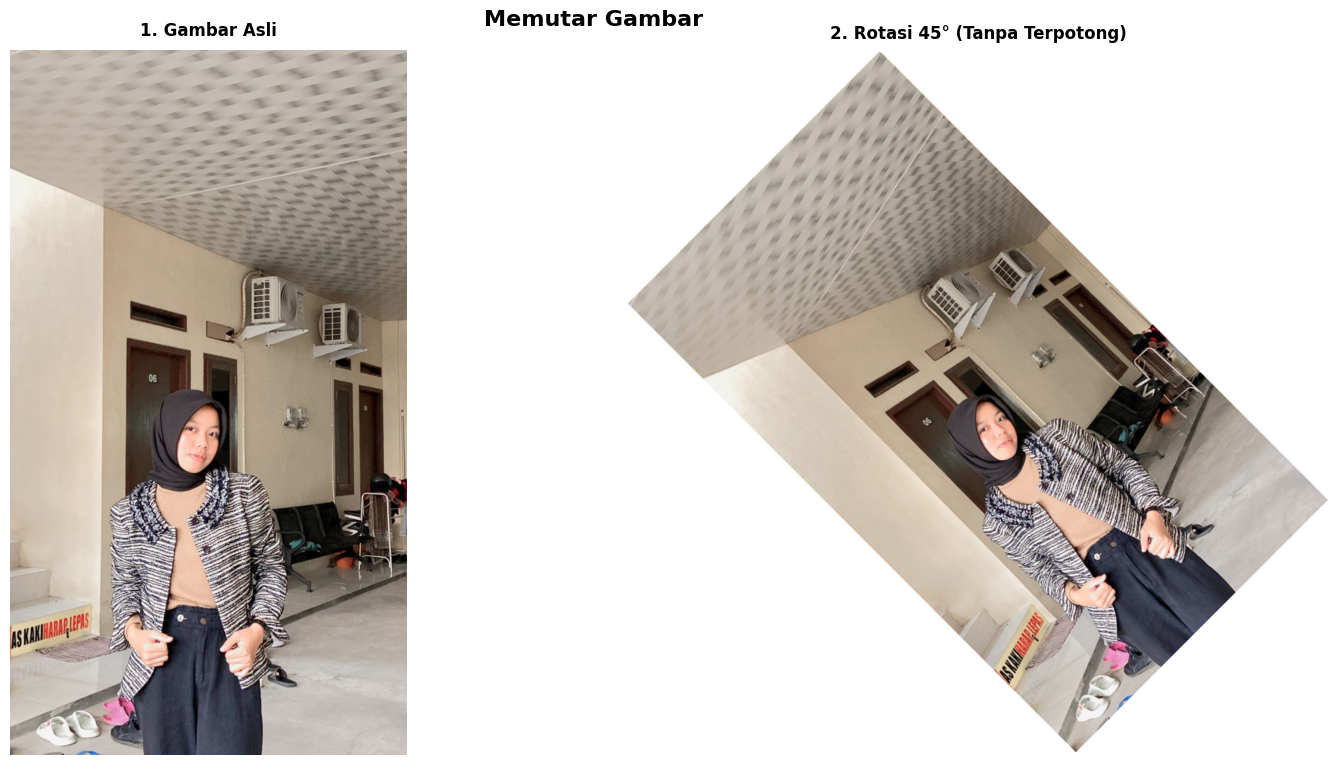

• Rotasi: 45° dengan canvas baru 1626x1626 px


In [41]:
rows, cols = img2_rgb.shape[:2] 

# Original Image 
img_original = img2_rgb.copy()

# Rotasi 45° TANPA TERPOTONG
angle = 45
M = cv2.getRotationMatrix2D((cols/2, rows/2), angle, 1) 

# Hitung dimensi canvas baru
cos = np.abs(M[0, 0]) 
sin = np.abs(M[0, 1]) 
new_width = int((rows * sin) + (cols * cos)) 
new_height = int((rows * cos) + (cols * sin)) 

# Sesuaikan translasi agar tetap di tengah canvas baru
M[0, 2] += (new_width / 2) - cols/2 
M[1, 2] += (new_height / 2) - rows/2 

# Rotasi dengan background putih
img_rotated = cv2.warpAffine(img2_rgb, M, (new_width, new_height), 
                            borderValue=(255, 255, 255))


# PLOT 2x3 Layout 
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Memutar Gambar', 
             fontsize=16, fontweight='bold', y=0.95)

# Baris pertama
axes[0].imshow(img_original) 
axes[0].set_title('1. Gambar Asli', fontsize=12, fontweight='bold', pad=10) 
axes[0].axis('off') 

axes[1].imshow(img_rotated) 
axes[1].set_title('2. Rotasi 45° (Tanpa Terpotong)', fontsize=12, fontweight='bold', pad=10) 
axes[1].axis('off') 

# Penyesuaian layout
plt.tight_layout()
plt.subplots_adjust(top=0.90, hspace=0.15, wspace=0.1)
plt.show()

# Informasi Parameter 
print(f"• Rotasi: {angle}° dengan canvas baru {new_width}x{new_height} px")

### **Hands-On: Menggeser Posisi Objek di dalam Gambar**

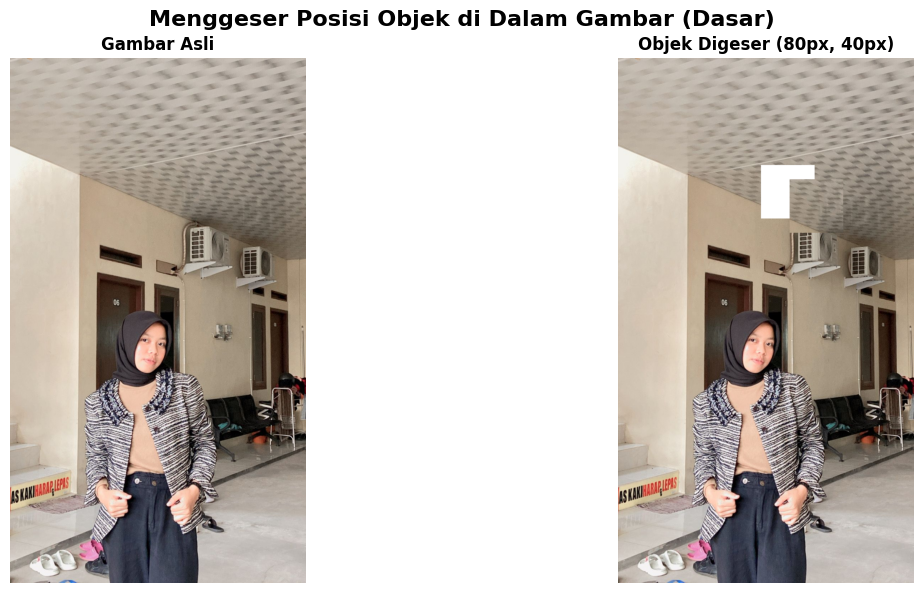

Objek awal: (y=300:450, x=400:550)
Digeser ke: (y=340:490, x=480:630)


In [42]:
# Tentukan area objek (misalnya kotak tengah)
obj = img2_rgb[300:450, 400:550].copy()
bg_obj = img2_rgb.copy()

# Hapus area lama (diganti putih)
bg_obj[300:450, 400:550] = 255

# Geser posisi objek
tx, ty = 80, 40  # geser ke kanan 80px, ke bawah 40px
bg_obj[300+ty:450+ty, 400+tx:550+tx] = obj

# Plot hasil
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Menggeser Posisi Objek di Dalam Gambar (Dasar)', fontsize=16, fontweight='bold')

axs[0].imshow(img_original)
axs[0].set_title('Gambar Asli', fontweight='bold')
axs[0].axis('off')

axs[1].imshow(bg_obj)
axs[1].set_title(f'Objek Digeser ({tx}px, {ty}px)', fontweight='bold')
axs[1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

print(f"Objek awal: (y=300:450, x=400:550)")
print(f"Digeser ke: (y={300+ty}:{450+ty}, x={400+tx}:{550+tx})")

### **Hands-On: Pengenalan Fungsi Menggambar**

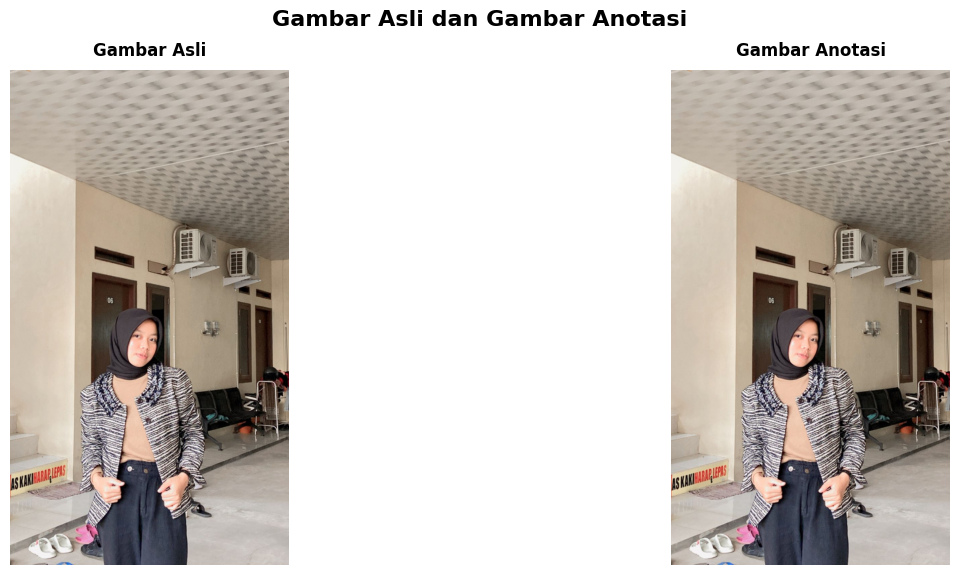

• Rectangle: koordinat (650,370) ke (800,500) - hijau, tebal 4px
• Text: 'DOSEN' pada (655,360) - merah, ukuran 1.0


In [43]:
# Anotasi (Rectangle & Text)
img_annotated = img2_rgb.copy() 
cv2.rectangle(img_annotated, (900, 300), (1300, 500), (0, 255, 0), 4)  # Hijau tebal
cv2.putText(img_annotated, 'Meonggg', (1000, 200), cv2.FONT_HERSHEY_SIMPLEX,  
            1.0, (255, 0, 0), 3)  # Merah tebal
shift_x = 500
shift_y = 500
# Anotasi pada hasil Translasi
img_final = img_annotated.copy()
cv2.rectangle(img_final, (650+shift_x, 370+shift_y), (800+shift_x, 500+shift_y), 
              (0, 255, 0), 4)
cv2.putText(img_final, 'TRANSFORMED', (655+shift_x, 360+shift_y), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 3)

# PLOT 1x2 Layout 
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Gambar Asli dan Gambar Anotasi', fontsize=16, fontweight='bold', y=0.95)

# Original Image
axes[0].imshow(img_original)
axes[0].set_title('Gambar Asli', fontsize=12, fontweight='bold', pad=10)
axes[0].axis('off')

# Annotated Image
axes[1].imshow(img_annotated)
axes[1].set_title('Gambar Anotasi', fontsize=12, fontweight='bold', pad=10)
axes[1].axis('off')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.85, wspace=0.3)
plt.show()

print(f"• Rectangle: koordinat (650,370) ke (800,500) - hijau, tebal 4px")
print(f"• Text: 'DOSEN' pada (655,360) - merah, ukuran 1.0")

**Penjelasan**
* OpenCV menggunakan fungsi `cv2.getRotationMatrix2D()` untuk membuat matriks rotasi 2D berdasarkan pusat, sudut, dan skala.
* Fungsi `cv2.warpAffine()` digunakan untuk menerapkan transformasi (rotasi, translasi, kombinasi) ke gambar dengan parameter matriks transformasi dan ukuran canvas baru.
* Translasi dibuat dengan matriks manual `np.float32([[1, 0, shift_x], [0, 1, shift_y]])` untuk menggeser posisi gambar.
* Fungsi `cv2.rectangle()` digunakan untuk menggambar kotak pada gambar dengan menentukan koordinat sudut, warna, dan ketebalan garis.
* Fungsi `cv2.putText()` digunakan untuk menambahkan teks pada gambar dengan menentukan posisi, jenis font, ukuran, warna, dan ketebalan huruf.
